<div style=" background-color:#0A2B07;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 5 DATA SCIENTIST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Segmentez des clients d'un site e-commerce
</h2>
</div>

## **INITIALISATION**

In [ ]:
# ============================================================
# LIBRAIRIES DE BASE
# ============================================================

# Manipulation de données
import pandas as pd
import numpy as np
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement et clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour plot 3D


In [ ]:
# Définir le dossier où sont stockés les fichiers CSV
data_path = r"C:\Users\barre\Documents\Pro\Reconversion_professionnelle\Formations\Data_Scientist_by_Openclassrooms\P05\data"

# Charger tous les fichiers CSV en utilisant le chemin centralisé
customers = pd.read_csv(f"{data_path}\\olist_customers_dataset.csv")
geolocation = pd.read_csv(f"{data_path}\\olist_geolocation_dataset.csv")
order_items = pd.read_csv(f"{data_path}\\olist_order_items_dataset.csv")
order_payments = pd.read_csv(f"{data_path}\\olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(f"{data_path}\\olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{data_path}\\olist_orders_dataset.csv")
products = pd.read_csv(f"{data_path}\\olist_products_dataset.csv")
sellers = pd.read_csv(f"{data_path}\\olist_sellers_dataset.csv")


In [ ]:
def profile_dataframe(df, table_name, primary_keys=None, verbose=True):
    """
    Profiling complet d'un DataFrame avec informations sur les colonnes
    et éventuellement sur la clé primaire, avec quartiles pour les colonnes numériques et dates.

    Arguments :
        df : DataFrame à analyser
        table_name : nom logique de la table (string)
        primary_keys : dictionnaire {nom_table: [liste_colonnes_identifiants]}
        verbose : bool, si True affiche les infos générales
    
    Retour :
        DataFrame contenant pour chaque colonne :
        - première valeur
        - type pandas
        - type détaillé (numérique, texte, date, booléen)
        - nombre de valeurs uniques
        - % doublons si clé primaire
        - % valeurs manquantes
        - % zéros (numérique)
        - min, max, médiane
        - 1er quartile (25%), 3ème quartile (75%)
        - moyenne (numérique)
    """
    n_rows, n_cols = df.shape

    # Gestion clé primaire
    pk_cols = []
    n_duplicates = None
    if primary_keys and table_name in primary_keys:
        pk_cols = [c for c in primary_keys[table_name] if c in df.columns]
        if pk_cols:
            n_duplicates = df.duplicated(subset=pk_cols, keep=False).sum()
    
    if verbose:
        print(f"\n=== Table : {table_name} ===")
        print(f"Taille : {n_rows} lignes × {n_cols} colonnes")
        if pk_cols:
            pk_str = "', '".join(pk_cols)
            print(f"Clé primaire : '{pk_str}' → {n_duplicates} doublons")
        else:
            if primary_keys and table_name in primary_keys:
                print("Clé primaire définie dans primary_keys mais colonnes manquantes dans le DataFrame")
            else:
                print("Clé primaire : non renseignée")
    
    results = []
    
    for col in df.columns:
        serie = df[col]
        first_value = serie.iloc[0]
        dtype = serie.dtype

        # type détaillé
        if pd.api.types.is_numeric_dtype(serie):
            detailed_type = "numérique"
        elif pd.api.types.is_bool_dtype(serie):
            detailed_type = "booléen"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            detailed_type = "date"
        else:
            detailed_type = "texte"
        
        n_unique = serie.nunique(dropna=False)
        pct_missing = round(serie.isna().mean() * 100, 2)
        
        if detailed_type == "numérique":
            pct_zeros = round((serie == 0).mean() * 100, 2)
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = round(serie.mean(), 2)
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        elif detailed_type == "date":
            pct_zeros = np.nan
            col_min = serie.min()
            col_max = serie.max()
            median = serie.median()
            mean = np.nan
            q25 = serie.quantile(0.25)
            q75 = serie.quantile(0.75)
        else:
            pct_zeros = np.nan
            col_min = np.nan
            col_max = np.nan
            median = np.nan
            mean = np.nan
            q25 = np.nan
            q75 = np.nan

        pct_duplicates = np.nan
        if col in pk_cols:
            pct_duplicates = round((1 - serie.nunique(dropna=False) / n_rows) * 100, 2)
        
        results.append({
            "column": col,
            "first_value": first_value,
            "dtype": dtype,
            "detailed_type": detailed_type,
            "n_unique": n_unique,
            "pct_duplicates": pct_duplicates,
            "pct_missing": pct_missing,
            "pct_zeros": pct_zeros,
            "min": col_min,
            "q25": q25,
            "median": median,
            "q75": q75,
            "max": col_max,
            "mean": mean
        })

    if verbose:
        print("\n--- Tableau de profil ---")
    
    return pd.DataFrame(results)


In [ ]:
def plot_distributions(df, columns, table_name="Table", save_path=None, show_values=False, color_dict=None):
    """
    Affiche la distribution d'une ou plusieurs colonnes d'un DataFrame.

    Arguments :
        df : DataFrame pandas
        columns : liste de colonnes ou une seule colonne (string)
        table_name : nom de la table, affiché dans le titre
        save_path : chemin pour sauvegarder la figure (optionnel, PNG, fond transparent)
        show_values : bool, si True affiche les valeurs au-dessus des barres / boxplots
        color_dict : dict, mapping valeur -> couleur pour barplots catégoriels
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    if isinstance(columns, str):
        columns = [columns]

    for col in columns:
        if col not in df.columns:
            print(f"Colonne '{col}' non trouvée dans le DataFrame.")
            continue

        serie = df[col]
        plt.figure(figsize=(14, 5))

        # Déterminer le type
        if pd.api.types.is_numeric_dtype(serie):
            type_col = "numérique"
        elif pd.api.types.is_datetime64_any_dtype(serie):
            type_col = "date"
        else:
            type_col = "catégoriel"

        # Échapper les underscores pour LaTeX dans le titre
        col_tex = col.replace("_", r"\_")
        table_tex = table_name.replace("_", r"\_")
        title_str = fr"Distribution de la variable $\mathbf{{\mathit{{{col_tex}}}}}$ de la table $\mathbf{{\mathit{{{table_tex}}}}}$ ({type_col})"

        if type_col in ["numérique", "date"]:
            # histogramme + boxplot
            plt.subplot(1, 2, 1)
            if pd.api.types.is_integer_dtype(serie) and serie.nunique() <= 20:
                bins = range(int(serie.min()), int(serie.max()) + 2)
                sns.histplot(serie, bins=bins, kde=False, color="forestgreen")
                plt.xticks(range(int(serie.min()), int(serie.max()) + 1))
            else:
                sns.histplot(serie, bins=30, kde=True, color="forestgreen")
            plt.ylabel("Fréquence")
            plt.xlabel("")
            plt.title(title_str, fontsize=12)

            plt.subplot(1, 2, 2)
            ax = sns.boxplot(x=serie, color="forestgreen")
            plt.xlabel("")
            plt.title("Boxplot", fontsize=12)

            if show_values:
                median = serie.median()
                plt.text(median, 0.5, f"median={median:.2f}", horizontalalignment='center', 
                         verticalalignment='bottom', color='black', fontsize=10)

        else:
            # barplot pour valeurs catégorielles
            counts = serie.value_counts()
            if color_dict:
                colors = [color_dict.get(v, "forestgreen") for v in counts.index]  # vert forêt par défaut
            else:
                colors = ["forestgreen"] * len(counts)
            ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)
            plt.ylabel("Fréquence")
            plt.xlabel("")
            plt.xticks(rotation=45)
            plt.title(title_str, fontsize=12)

            if show_values:
                for i, v in enumerate(counts.values):
                    ax.text(i, v + max(counts.values)*0.01, str(v), ha='center', fontsize=9)

        plt.tight_layout(rect=[0, 0, 1, 0.9])

        if save_path:
            plt.savefig(save_path, transparent=True)
        plt.show()


# color_segment = {
#     "loyaux": "#2851FF",
#     "loyalistes potentiels": "#092AAE",
#     "Champions": "#15C574",
#     "a réactiver": "#1D8C56",
#     "perdus": "#910909",
#     "a risque": "#E72C26"
# }
# plot_distributions(rfm_v2, ["segment"], table_name="rfm_v2", show_values=True, color_dict=color_segment)


In [ ]:
def value_frequencies(df, column):
    """
    Affiche un tableau avec la fréquence des valeurs uniques d'une colonne.
    """
    if column not in df.columns:
        print(f"Colonne '{column}' non trouvée dans le DataFrame.")
        return
    
    freqs = df[column].value_counts(dropna=False)
    freq_table = pd.DataFrame({
        "valeur": freqs.index,
        "fréquence": freqs.values,
        "pourcentage": (freqs.values / len(df) * 100).round(2)
    })
    return freq_table


# **TODO**

| Étape | Objectif | Actions concrètes | Référentiel CE associé | Avancement |
|-------|----------|-----------------|----------------------|-----------|
| 1. Sélection des features | Choisir les variables pertinentes pour le clustering | - Vérifier la qualité et la variance des variables<br>- Retirer les colonnes redondantes ou peu discriminantes<br>- S’assurer que les variables catégorielles sont encodées et les variables continues normalisées | CE1, CE2, CE3, CE4 | ✅ Terminé |
| 2. Prétraitement | Préparer le dataset pour l’algorithme | - Remplacer les NaN si nécessaire ou filtrer<br>- Appliquer StandardScaler ou MinMaxScaler sur les variables continues<br>- Vérifier les variables binaires et one-hot | CE1, CE3, CE4 | ✅ Terminé (df_cluster prêt) |
| 3. Clustering initial | Se familiariser avec l’algorithme | - Lancer un k-means avec 3 à 6 clusters<br>- Observer les résultats initiaux | CE5, CE6, CE8 | ⬜ Pas encore fait |
| 4. Choix du nombre optimal de clusters | Déterminer le nombre de clusters pertinent | - Méthode data-driven : silhouette, elbow, gap statistic<br>- Méthode métier : cohérence avec le business et la lisibilité | CE6, CE1 | ⬜ Pas encore fait |
| 5. Évaluation du clustering | Mesurer la qualité du modèle | - Calculer silhouette score et inertia<br>- Vérifier la stabilité à plusieurs initialisations (random_state)<br>- Analyser la répartition des clusters | CE1, CE2, CE3, CE4, CE5 | ⬜ Pas encore fait |
| 6. Interprétation des clusters | Caractériser les clusters en lien avec les features | - Calculer les moyennes, médianes et distributions par cluster<br>- Identifier les comportements typiques pour chaque cluster | CE5, CE6 | ⬜ Pas encore fait |
| 7. Comparaison d’algorithmes | Tester différentes méthodes | - KMeans vs Agglomerative / DBSCAN (si pertinent)<br>- Comparer scores et stabilité | CE9, CE2, CE4, CE5 | ⬜ Pas encore fait |
| 8. Validation métier | S’assurer que le clustering est compréhensible et exploitable | - Vérifier la tangibilité des clusters pour le business<br>- Ajuster le nombre de clusters ou les features si nécessaire | CE5, CE6 | ⬜ Pas encore fait |
| 9. Stratégie nouveaux clients | Définir comment assigner de nouveaux clients | - Standardiser les nouvelles données avec les mêmes transformations<br>- Affecter le cluster le plus proche (distance euclidienne ou centroid) | CE7, CE8 | ⬜ Pas encore fait |
| 10. Documentation et maintenance | Assurer la traçabilité et reproductibilité | - Commenter le code<br>- Respecter PEP8<br>- Documenter les choix d’algorithme, hyper-paramètres et features | CE7, CE9 | ⬜ Pas encore fait |

# **CADRAGE**

**Objectif métier de la segmentation**
- Identifier des groupes de clients homogènes pour adapter les actions marketing

**Usage marketing attendu**
- Campagnes ciblées, offres personnalisées, priorisation des clients, relances, fidélisation

**Contraintes**
- Interprétabilité : les segments doivent pouvoir être expliqués aux équipes marketing
- Stabilité : segmentation stable dans le temps pour comparer les clusters
- Recalcul : prévoir la fréquence et la méthode pour mettre à jour la segmentation


# **ANALYSE EXPLORATOIRE ET NETTOYAGE DES DONNÉES**

In [ ]:
print('customer', customers.columns.tolist())
print('geolocation', geolocation.columns.tolist())
print('order_items', order_items.columns.tolist())
print('order_payments', order_payments.columns.tolist())
print('order_reviews', order_reviews.columns.tolist())
print('orders', orders.columns.tolist())
print('products', products.columns.tolist())
print('sellers', sellers.columns.tolist())

customer ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
geolocation ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
order_items ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
order_payments ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
order_reviews ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
orders ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
products ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', '

In [ ]:
primary_keys = {
    "customers": ["customer_unique_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_city"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"]
}

## **CUSTOMER**

In [ ]:
# # Suppression des doublons sur customer_unique_id
# # customers = customers.drop_duplicates(subset=['customer_unique_id'], keep='first')

# # Affichage du profil
# profile_customers = profile_dataframe(customers, "customers", primary_keys)
# display(profile_customers)

# # Affichage de la distribution
# plot_distributions(customers, "customer_state", table_name="customers")

## **GEOLOCALISATION**

In [ ]:
# Suppression des doublons
geolocation = geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geolocation_city'], keep='first')

# # Affichage du profil
# profile_geolocation = profile_dataframe(geolocation, "geolocation", primary_keys)
# # display(profile_geolocation)

# # Affichage de la distribution
# plot_distributions(geolocation, "geolocation_state", table_name="geolocation")

## **ORDER_ITEMS**

In [ ]:
# Conversion des colonnes de date
cols_to_convert = ['shipping_limit_date']
order_items[cols_to_convert] = order_items[cols_to_convert].apply(pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce')

# # Affichage du profil
# profile_order_items = profile_dataframe(order_items, "order_items", primary_keys)
# display(profile_order_items)

# # Affichage de la distribution
# plot_distributions(order_items, ["price", "freight_value", "order_item_id"], table_name="order_items")

## **ORDER_PAYMENTS**

In [ ]:
# # Affichage du profil
# profile_order_payments = profile_dataframe(order_payments, "order_payments", primary_keys)
# display(profile_order_payments)

# # Affichage de la distribution
# plot_distributions(order_payments, ["payment_sequential", "payment_type", "payment_value"], table_name="order_payments")

## **ORDER_REVIEW**

In [ ]:
# Suppression des doublons sur review_id
# order_reviews = order_reviews.drop_duplicates(subset=['review_id'], keep='first')

# Conversion des colonnes de date
cols_to_convert = ['review_creation_date', 'review_answer_timestamp']
order_reviews[cols_to_convert] = order_reviews[cols_to_convert].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# # Affichage du profil
# profile_order_reviews = profile_dataframe(order_reviews, "order_reviews", primary_keys)
# display(profile_order_reviews)

# # Affichage de la distribution
# plot_distributions(order_reviews, "review_score", table_name="order_reviews")


## **ORDERS**

In [ ]:
# Conversion des colonnes de date
cols_to_convert_orders = ['order_purchase_timestamp', 'order_approved_at', 
                          'order_delivered_carrier_date', 'order_delivered_customer_date', 
                          'order_estimated_delivery_date']
orders[cols_to_convert_orders] = orders[cols_to_convert_orders].apply(
    pd.to_datetime, format='%Y-%m-%d %H:%M:%S', errors='coerce'
)

# # Affichage du profil
# profile_orders = profile_dataframe(orders, "orders", primary_keys)
# display(profile_orders)

# # Affichage de la distribution
# plot_distributions(orders, ["order_status", "order_purchase_timestamp", "order_delivered_customer_date"], table_name="orders")

## **PRODUCTS**

In [ ]:
# # Affichage du profil
# profile_products = profile_dataframe(products, "products", primary_keys)
# display(profile_products)

# # Affichage de la distribution
# plot_distributions(products, ["product_weight_g", "product_length_cm"], table_name="products")

In [ ]:
# value_frequencies(products, "product_category_name")

## **SELLERS**

In [ ]:
# # Affichage du profil
# profile_sellers = profile_dataframe(sellers, "sellers", primary_keys)
# display(profile_sellers)

# # Affichage de la distribution
# plot_distributions(sellers, "seller_state", table_name="sellers")

## **1ER FEATURE ENGINEERING**

In [ ]:
# ============================================================
# 1. AGRÉGATION AU NIVEAU COMMANDE (MONETARY)
# ============================================================

order_value = (
    order_items
    .groupby('order_id', as_index=False)
    .agg(
        order_total_value=('price', 'sum'),
        freight_total=('freight_value', 'sum')
    )
)

# Montant total commande = produits + frais de port
order_value['order_total_value'] += order_value['freight_total']


# ============================================================
# 2. ENRICHISSEMENT DES COMMANDES
# ============================================================

orders_rfm = (
    orders
    .merge(order_value, on='order_id', how='left')
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

orders_rfm['order_purchase_timestamp'] = pd.to_datetime(
    orders_rfm['order_purchase_timestamp']
)


# ============================================================
# 3. AGRÉGATION CLIENT — VARIABLES RFM
# ============================================================

df_rfm = (
    orders_rfm
    .groupby('customer_unique_id', as_index=False)
    .agg(
        frequency=('order_id', 'nunique'),                 # Nombre de commandes
        monetary=('order_total_value', 'sum'),             # Dépense totale
        last_order_date=('order_purchase_timestamp', 'max')
    )
)


# ============================================================
# 4. CALCUL DE LA RECENCY
# ============================================================

# Date de référence = dernière date de commande du dataset
reference_date = df_rfm['last_order_date'].max()

df_rfm['recency'] = (
    reference_date - df_rfm['last_order_date']
).dt.days


# ============================================================
# 5. TABLE FINALE RFM
# ============================================================

df_rfm = df_rfm[[
    'customer_unique_id',
    'frequency',
    'recency',
    'monetary'
]]


In [ ]:
# ==============================
# PROFIL
# ==============================

# --- Profil du dataframe ---
profile_df_rfm = profile_dataframe(
    df_rfm,
    table_name="df_rfm",
    primary_keys=primary_keys
)
display(profile_df_rfm)

# --- Sélection des variables pertinentes pour les distributions ---
distribution_cols = (
    df_rfm
    .select_dtypes(include=["int64", "float64"])
    .loc[:, lambda df: df.nunique() > 2]                 # enlève constantes / quasi constantes
    .loc[:, lambda df: df.isna().mean() < 0.3]           # enlève colonnes trop manquantes
    .columns
    .tolist()
)

# --- Exclure les variables binaires (0/1) ---
distribution_cols = [
    col for col in distribution_cols
    if not set(df_rfm[col].dropna().unique()).issubset({0, 1})
]

# --- Affichage des distributions ---
# plot_distributions(
#     df_rfm,
#     distribution_cols,
#     table_name="df_rfm"
# )



=== Table : df_rfm ===
Taille : 96096 lignes × 4 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,96096,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,frequency,1,int64,numérique,9,NaN,0.0,0.0,1.0,1.00,1.00,1.0000,17.00,1.03
2,recency,160,int64,numérique,630,NaN,0.0,0.0,0.0,163.00,268.00,397.0000,772.00,287.74
3,monetary,141.9,float64,numérique,31718,NaN,0.0,0.7,0.0,62.39,107.27,182.2375,13664.08,164.87


# **1ER ENTRAÎNEMENT**

In [ ]:
# ==============================
# PRÉPARATION DES DONNÉES POUR K-MEANS
# ==============================

# --- Copie de travail ---
df_k_means_v1 = df_rfm.copy()

# --- Exclusion explicite de l'identifiant ---
id_col = 'customer_unique_id'
df_k_means_v1 = df_k_means_v1.drop(columns=[id_col])

# --- Sélection uniquement des colonnes numériques ---
df_k_means_v1 = df_k_means_v1.select_dtypes(include=['int64', 'float64'])

# --- Standardisation des variables RFM ---
scaler = StandardScaler()
df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)

# --- Vérification finale ---
print("Shape df_k_means_v1 :", df_k_means_v1.shape)

profile_df_k_means_v1 = profile_dataframe(
    df_k_means_v1,
    "df_k_means_v1",
    primary_keys=None
)
display(profile_df_k_means_v1)

Shape df_k_means_v1 : (96096, 3)

=== Table : df_k_means_v1 ===
Taille : 96096 lignes × 3 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


C:\Users\barre\AppData\Local\Temp\ipykernel_21988\253354213.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.16236828 -0.16236828 -0.16236828 ... -0.16236828 -0.16236828
 -0.16236828]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)
C:\Users\barre\AppData\Local\Temp\ipykernel_21988\253354213.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.83262149 -0.81306654  1.93766244 ...  2.14624852 -0.78047497
  1.59219173]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_k_means_v1.loc[:, :] = scaler.fit_transform(df_k_means_v1)


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,frequency,-0.162368,float64,numérique,9,NaN,0.0,0.0,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.0
1,recency,-0.832621,float64,numérique,630,NaN,0.0,0.0,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.0
2,monetary,-0.100783,float64,numérique,31227,NaN,0.0,0.0,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.0


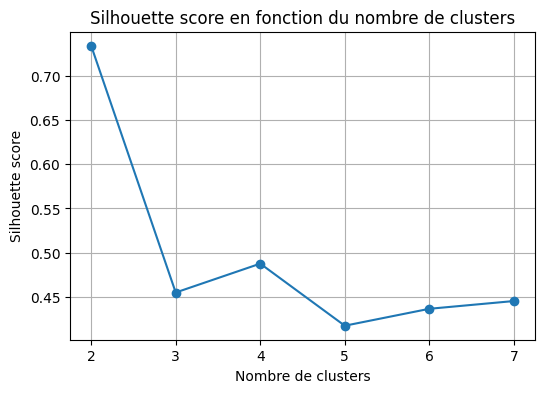

,n_clusters,silhouette_score
0,2,0.734130
1,3,0.454816
2,4,0.487504
3,5,0.417231
4,6,0.436395
5,7,0.445165


Nombre optimal de clusters selon silhouette : 2


In [ ]:
# # ==============================
# # SILOUETTE SCORE
# # ==============================

# # --- Paramètres ---
# range_n_clusters = range(2, 8)
# silhouette_scores = []
# random_state = 42  # Pour reproductibilité

# # Préparer les données pour le clustering (ignore colonne cluster si elle existe)
# df_for_clustering = df_k_means_v1.drop(columns=['cluster_init'], errors='ignore')

# # --- Calcul des scores silhouette ---
# for k in range_n_clusters:
#     kmeans = KMeans(n_clusters=k, random_state=random_state)
#     labels = kmeans.fit_predict(df_for_clustering)
#     score = silhouette_score(df_for_clustering, labels)
#     silhouette_scores.append(score)

# # --- Affichage de la courbe ---
# plt.figure(figsize=(6,4))
# plt.plot(range_n_clusters, silhouette_scores, marker='o')
# plt.title("Silhouette score en fonction du nombre de clusters")
# plt.xlabel("Nombre de clusters")
# plt.ylabel("Silhouette score")
# plt.grid(True)
# plt.show()

# # --- Tableau des résultats ---
# results_df = pd.DataFrame({
#     "n_clusters": list(range_n_clusters),
#     "silhouette_score": silhouette_scores
# })
# display(results_df)

# # --- Meilleur nombre de clusters selon silhouette ---
# best_k = results_df.loc[results_df['silhouette_score'].idxmax(), 'n_clusters']
# print("Nombre optimal de clusters selon silhouette :", best_k)


n_clusters	silhouette_score

0	2	0.734130

1	3	0.454816

2	4	0.487504

3	5	0.417231

4	6	0.436395

5	7	0.445165

Nombre optimal de clusters selon silhouette : 2

In [ ]:
# ==============================
# K-MEANS À 2 CLUSTERS
# ==============================

n_clusters_2 = 2
random_state = 42

# --- Fit KMeans 2 clusters ---
kmeans_rfm_2_clusters = KMeans(n_clusters=n_clusters_2, random_state=random_state)
df_k_means_v1['cluster'] = kmeans_rfm_2_clusters.fit_predict(df_k_means_v1.drop(columns=['cluster_init'], errors='ignore'))

# --- Vérifications quantitatives ---
inertia = kmeans_rfm_2_clusters.inertia_
sil_score = silhouette_score(df_k_means_v1.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
                             df_k_means_v1['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")

# --- Distribution des clusters ---
print("\nDistribution des clusters :")
print(df_k_means_v1['cluster'].value_counts())

Inertia (somme des distances au centre) : 208205.30
Silhouette score : 0.734

Distribution des clusters :
cluster
0    93088
1     3008
Name: count, dtype: int64


In [ ]:
# # ==============================
# # K-MEANS À 4 CLUSTERS
# # ==============================

# n_clusters_4 = 4
# random_state = 42

# # --- Fit KMeans 4 clusters ---
# kmeans_rfm_4_clusters = KMeans(n_clusters=n_clusters_4, random_state=random_state)
# df_k_means_v1['cluster'] = kmeans_rfm_4_clusters.fit_predict(df_k_means_v1.drop(columns=['cluster_init'], errors='ignore'))

# # --- Vérifications quantitatives ---
# inertia = kmeans_rfm_4_clusters.inertia_
# sil_score = silhouette_score(df_k_means_v1.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
#                              df_k_means_v1['cluster'])

# print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
# print(f"Silhouette score : {sil_score:.3f}")

# # --- Distribution des clusters ---
# print("\nDistribution des clusters :")
# print(df_k_means_v1['cluster'].value_counts())

Inertia (somme des distances au centre) : 95768.48
Silhouette score : 0.487

Distribution des clusters :
cluster
0    52065
1    38591
2     2963
3     2477
Name: count, dtype: int64


Inertia (somme des distances au centre) : 95768.48

Silhouette score : 0.487

Distribution des clusters :

cluster

0    52065

1    38591

2     2963

3     2477

Name: count, dtype: int64

# **INTERPRÉTATION DES CLUSTERS DE K-MEANS_V1**

,nb_clients,recency,monetary,frequency
cluster,,,,
0,52065,-0.72,-0.13,-0.16
1,38591,0.98,-0.14,-0.16
2,2963,-0.13,0.53,5.05
3,2477,0.01,4.41,-0.09


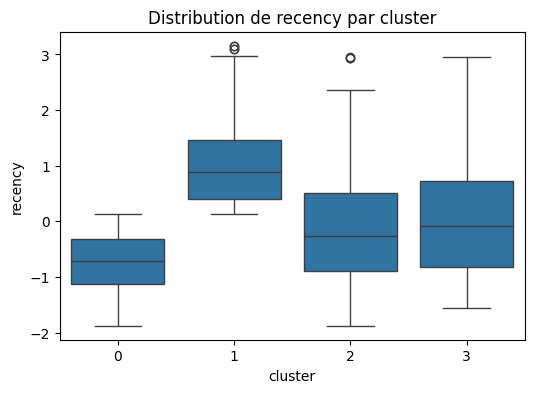

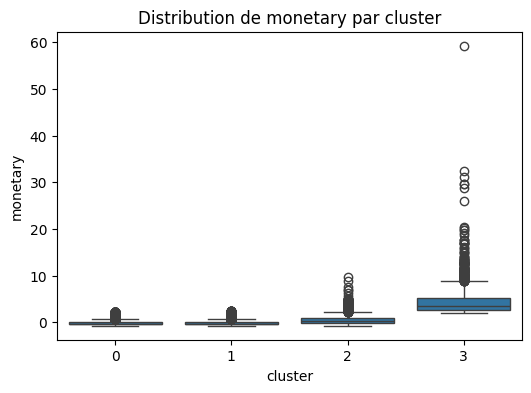

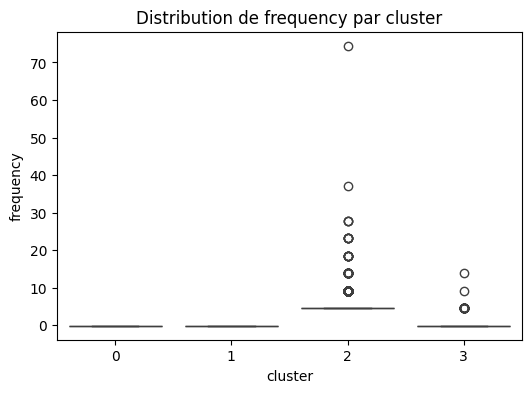

In [ ]:
# ==============================
# PROFIL MOYEN DES CLUSTERS : TABLEAU + HEATMAP
# ==============================

# --- Variables continues d’intérêt ---
cols_continuous = ['recency', 'monetary', 'frequency']
cols_continuous = [c for c in cols_continuous if c in df_k_means_v1.columns]

# --- Calcul des moyennes par cluster ---
cluster_means = df_k_means_v1.groupby('cluster')[cols_continuous].mean().round(2)

# --- Affichage du tableau des valeurs ---
display(cluster_means)

# --- Affichage heatmap ---
plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_means.T,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.title("Profil moyen des clusters")
plt.show()


In [ ]:
# ==============================
# DISTRIBUTIONS DES VARIABLES PAR CLUSTER
# ==============================

features_to_plot = ['recency', 'monetary', 'frequency']
features_to_plot = [f for f in features_to_plot if f in df_k_means_v1.columns]

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='cluster', y=feature, data=df_k_means_v1)
    plt.title(f"Distribution de {feature} par cluster")
    plt.show()


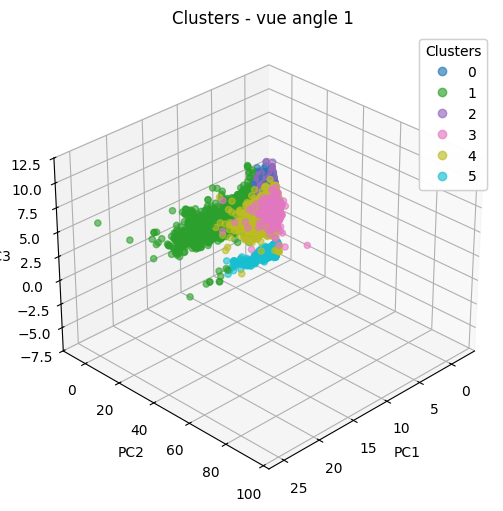

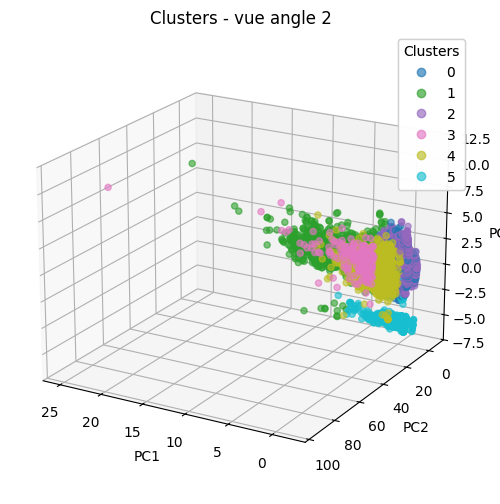

In [ ]:
# ==============================
# PCA 3D DES CLUSTERS
# ==============================

pca = PCA(n_components=3)
X_pca = pca.fit_transform(df_k_means_v1.drop(columns=['cluster', 'cluster_init'], errors='ignore'))

# --- Fonction pour afficher le scatter 3D avec angle personnalisé ---
def plot_3d_clusters(X, labels, elev=30, azim=45, title="Visualisation 3D des clusters"):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        X[:,0], X[:,1], X[:,2],
        c=labels, cmap='tab10', alpha=0.6
    )
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)
    plt.show()

# --- Angle 1 ---
plot_3d_clusters(X_pca, df_k_means_v1['cluster'], elev=30, azim=45, title="Clusters - vue angle 1")

# --- Angle 2 ---
plot_3d_clusters(X_pca, df_k_means_v1['cluster'], elev=20, azim=120, title="Clusters - vue angle 2")

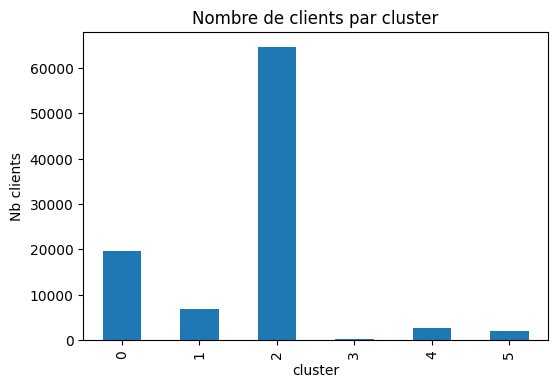

In [ ]:
# ==============================
# RÉPARTITION DES CLIENTS PAR CLUSTERS
# ==============================

counts = df_k_means_v1['cluster'].value_counts().sort_index()

# barplot
ax = counts.plot(kind='bar', figsize=(6, 4), color='forestgreen')

# titres et labels
ax.set_title("Nombre de clients par cluster")
ax.set_ylabel("Nb clients")

# ajout des valeurs au-dessus des barres
for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
# # ============================================================
# # 1. AGRÉGATION AU NIVEAU COMMANDE
# # ============================================================

# order_items_sum = (
#     order_items
#     .groupby('order_id', as_index=False)
#     .agg(
#         order_total_value=('price', 'sum'),          # Montant total produits
#         freight_total=('freight_value', 'sum'),      # Frais de port
#         n_products=('product_id', 'nunique'),        # Nb produits distincts
#         n_unique_sellers=('seller_id', 'nunique')    # Nb vendeurs distincts
#     )
# )

# order_items_sum['order_total_value'] += order_items_sum['freight_total']


# # ============================================================
# # 2. ENRICHISSEMENT COMMANDES
# # ============================================================

# orders_enriched = (
#     orders
#     .merge(order_items_sum, on='order_id', how='left')
#     .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
# )

# orders_enriched['order_purchase_timestamp'] = pd.to_datetime(
#     orders_enriched['order_purchase_timestamp']
# )


# # ============================================================
# # 3. FEATURES TEMPORELLES COMMANDE
# # ============================================================

# orders_enriched['order_weekend'] = (
#     orders_enriched['order_purchase_timestamp'].dt.weekday >= 5
# )

# orders_enriched['order_month'] = orders_enriched['order_purchase_timestamp'].dt.month


# # ============================================================
# # 4. FEATURES PRODUITS / CATÉGORIES
# # ============================================================

# order_products = (
#     order_items
#     .merge(products, on='product_id', how='left')
#     .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
#     .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
# )

# order_products['product_volume'] = (
#     order_products['product_length_cm'] *
#     order_products['product_height_cm'] *
#     order_products['product_width_cm']
# )


# # ============================================================
# # 5. AGRÉGATION CATÉGORIES CLIENT
# # ============================================================

# # Nombre de catégories distinctes
# n_unique_categories = (
#     order_products
#     .groupby('customer_unique_id')['product_category_name']
#     .nunique()
#     .reset_index(name='n_unique_categories')
# )

# # Catégorie dominante
# category_dist = (
#     order_products
#     .groupby(['customer_unique_id', 'product_category_name'])
#     .size()
#     .reset_index(name='cnt')
# )

# max_category_pct = (
#     category_dist
#     .assign(
#         pct=lambda x: x['cnt'] /
#         x.groupby('customer_unique_id')['cnt'].transform('sum')
#     )
#     .groupby('customer_unique_id')['pct']
#     .max()
#     .reset_index(name='max_category_pct')
# )

# # Top N catégories binaires
# TOP_N = 10
# top_categories = (
#     order_products['product_category_name']
#     .value_counts()
#     .head(TOP_N)
#     .index
# )

# category_binary = (
#     order_products
#     .assign(flag=1)
#     .pivot_table(
#         index='customer_unique_id',
#         columns='product_category_name',
#         values='flag',
#         aggfunc='max',
#         fill_value=0
#     )
#     .reindex(columns=top_categories, fill_value=0)
#     .add_prefix('cat_')
#     .reset_index()
# )

# # Nombre de catégories parmi le top N
# category_binary['n_categories_topN'] = (
#     category_binary.filter(like='cat_').sum(axis=1)
# )


# # ============================================================
# # 6. FEATURES PRODUITS MOYENS
# # ============================================================

# product_means = (
#     order_products
#     .groupby('customer_unique_id')
#     .agg(
#         avg_weight=('product_weight_g', 'mean'),
#         avg_volume=('product_volume', 'mean'),
#         avg_product_photos=('product_photos_qty', 'mean')
#     )
#     .reset_index()
# )


# # ============================================================
# # 7. AGRÉGATION CLIENT – COMMANDES
# # ============================================================

# client_level = (
#     orders_enriched
#     .groupby('customer_unique_id', as_index=False)
#     .agg(
#         first_order_date=('order_purchase_timestamp', 'min'),
#         last_order_date=('order_purchase_timestamp', 'max'),
#         frequency_orders=('order_id', 'nunique'),
#         total_products=('n_products', 'sum'),
#         monetary_total=('order_total_value', 'sum'),
#         monetary_avg=('order_total_value', 'mean'),
#         max_order_value=('order_total_value', 'max'),
#         min_order_value=('order_total_value', 'min'),
#         max_products_per_order=('n_products', 'max'),
#         n_unique_sellers=('n_unique_sellers', 'sum'),
#         weekend_order_pct=('order_weekend', 'mean')
#     )
# )


# # ============================================================
# # 8. FEATURES TEMPORELLES CLIENT
# # ============================================================

# last_date = client_level['last_order_date'].max()

# client_level['recency_days'] = (
#     last_date - client_level['last_order_date']
# ).dt.days

# client_level['days_since_first_order'] = (
#     last_date - client_level['first_order_date']
# ).dt.days


# # ============================================================
# # 9. FEATURES REVIEWS
# # ============================================================

# client_reviews = (
#     order_reviews
#     .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
#     .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
#     .assign(positive=lambda x: x['review_score'] >= 4)
#     .groupby('customer_unique_id')
#     .agg(
#         n_review_total=('review_id', 'nunique'),
#         avg_review_score=('review_score', 'mean'),
#         pct_positive_reviews=('positive', 'mean')
#     )
#     .reset_index()
# )

# client_level = client_level.merge(client_reviews, on='customer_unique_id', how='left')
# client_level[['n_review_total', 'avg_review_score', 'pct_positive_reviews']] = (
#     client_level[['n_review_total', 'avg_review_score', 'pct_positive_reviews']].fillna(0)
# )

# client_level['review_count_per_order'] = (
#     client_level['n_review_total'] / client_level['frequency_orders']
# )


# # ============================================================
# # 10. FEATURES PAIEMENT
# # ============================================================

# payments_enriched = (
#     order_payments
#     .merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
#     .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
# )

# payment_mode = (
#     payments_enriched
#     .groupby(['customer_unique_id', 'payment_type'])
#     .size()
#     .reset_index(name='cnt')
#     .sort_values(['customer_unique_id', 'cnt'], ascending=False)
#     .drop_duplicates('customer_unique_id')
#     .pivot_table(
#         index='customer_unique_id',
#         columns='payment_type',
#         values='cnt',
#         fill_value=0
#     )
#     .reset_index()
#     .add_prefix('payment_')
# )


# # ============================================================
# # 11. FUSIONS FINALES + GESTION DES NAN
# # ============================================================

# client_level = (
#     client_level
#     .merge(n_unique_categories, on='customer_unique_id', how='left')
#     .merge(max_category_pct, on='customer_unique_id', how='left')
#     .merge(product_means, on='customer_unique_id', how='left')
#     .merge(category_binary, on='customer_unique_id', how='left')
#     .merge(payment_mode, left_on='customer_unique_id', right_on='payment_customer_unique_id', how='left')
# )

# # ------------------------------------------------------------
# # Remplacement des NaN par 0
# # ------------------------------------------------------------

# # Pourquoi : les NaN correspondent aux clients sans commandes ou sans paiement
# # Logique : si le client n'a jamais commandé, ou n'a jamais utilisé ce mode de paiement,
# # on met 0 pour que le K-means comprenne "absence de commande / catégorie / paiement".

# # Variables liées aux commandes :
# cmd_cols = [
#     'first_order_date', 'last_order_date',       # dates → on peut mettre 0 ou la date minimale si nécessaire
#     'monetary_avg', 'max_order_value', 'min_order_value',
#     'max_products_per_order',
#     'n_unique_categories', 'max_category_pct',
#     'avg_weight', 'avg_volume', 'avg_product_photos',
#     'n_categories_topN'
# ]

# # Remplacer toutes ces colonnes par 0 si NaN
# client_level[cmd_cols] = client_level[cmd_cols].fillna(0)

# # Variables binaires pour les catégories : NaN → 0 (absence de la catégorie)
# cat_cols = [c for c in client_level.columns if c.startswith('cat_')]
# client_level[cat_cols] = client_level[cat_cols].fillna(0)

# # Variables liées aux reviews : NaN → 0 (client sans review)
# review_cols = ['n_review_total', 'avg_review_score', 'pct_positive_reviews', 'review_count_per_order']
# client_level[review_cols] = client_level[review_cols].fillna(0)

# # Variables de paiement : NaN → 0 (client sans paiement enregistré pour ce type)
# payment_cols = [c for c in client_level.columns if c.startswith('payment_')]
# client_level[payment_cols] = client_level[payment_cols].fillna(0)



In [ ]:
# # ============================================================
# # PROFIL
# # ============================================================

# # Profil du dataframe
# profile_client_level = profile_dataframe(
#     client_level,
#     table_name="client_level",
#     primary_keys=primary_keys
# )
# display(profile_client_level)

# # Sélection des variables pertinentes pour les distributions
# distribution_cols = (
#     client_level
#     .select_dtypes(include=["int64", "float64"])
#     .loc[:, lambda df: df.nunique() > 2]                 # enlève constantes / quasi constantes
#     .loc[:, lambda df: df.isna().mean() < 0.3]           # enlève colonnes trop manquantes
#     .columns
#     .tolist()
# )

# # Exclure les variables binaires (0/1)
# distribution_cols = [
#     col for col in distribution_cols
#     if not set(client_level[col].dropna().unique()).issubset({0, 1})
# ]

# # Affichage des distributions
# # plot_distributions(
# #     client_level,
# #     distribution_cols,
# #     table_name="client_level"
# # )



=== Table : client_level ===
Taille : 96096 lignes × 40 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,customer_unique_id,0000366f3b9a7992bf8c76cfdf3221e2,object,texte,96096,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,first_order_date,2018-05-10 10:56:27,datetime64[ns],date,95837,NaN,0.0,NaN,2016-09-04 21:15:19,2017-09-11 19:52:06,2018-01-18 13:33:08,2018-05-04 10:38:45,2018-10-17 17:30:18,NaN
2,last_order_date,2018-05-10 10:56:27,datetime64[ns],date,95834,NaN,0.0,NaN,2016-09-04 21:15:19,2017-09-15 09:04:17.249999872,2018-01-21 19:39:16,2018-05-06 20:14:49.750000128,2018-10-17 17:30:18,NaN
3,frequency_orders,1,int64,numérique,9,NaN,0.0,0.00,1,1.0,1.0,1.0,17,1.03
4,total_products,1.0,float64,numérique,12,NaN,0.0,0.70,0.0,1.0,1.0,1.0,16.0,1.07
5,monetary_total,141.9,float64,numérique,31718,NaN,0.0,0.70,0.0,62.39,107.27,182.2375,13664.08,164.87
6,monetary_avg,141.9,float64,numérique,31873,NaN,0.0,0.70,0.0,61.73,105.22,176.3225,13664.08,159.91
7,max_order_value,141.9,float64,numérique,30725,NaN,0.0,0.70,0.0,61.8775,105.87,177.99,13664.08,161.41
8,min_order_value,141.9,float64,numérique,30350,NaN,0.0,0.70,0.0,60.5375,103.55,174.82,13664.08,158.47
9,max_products_per_order,1.0,float64,numérique,9,NaN,0.0,0.70,0.0,1.0,1.0,1.0,8.0,1.03


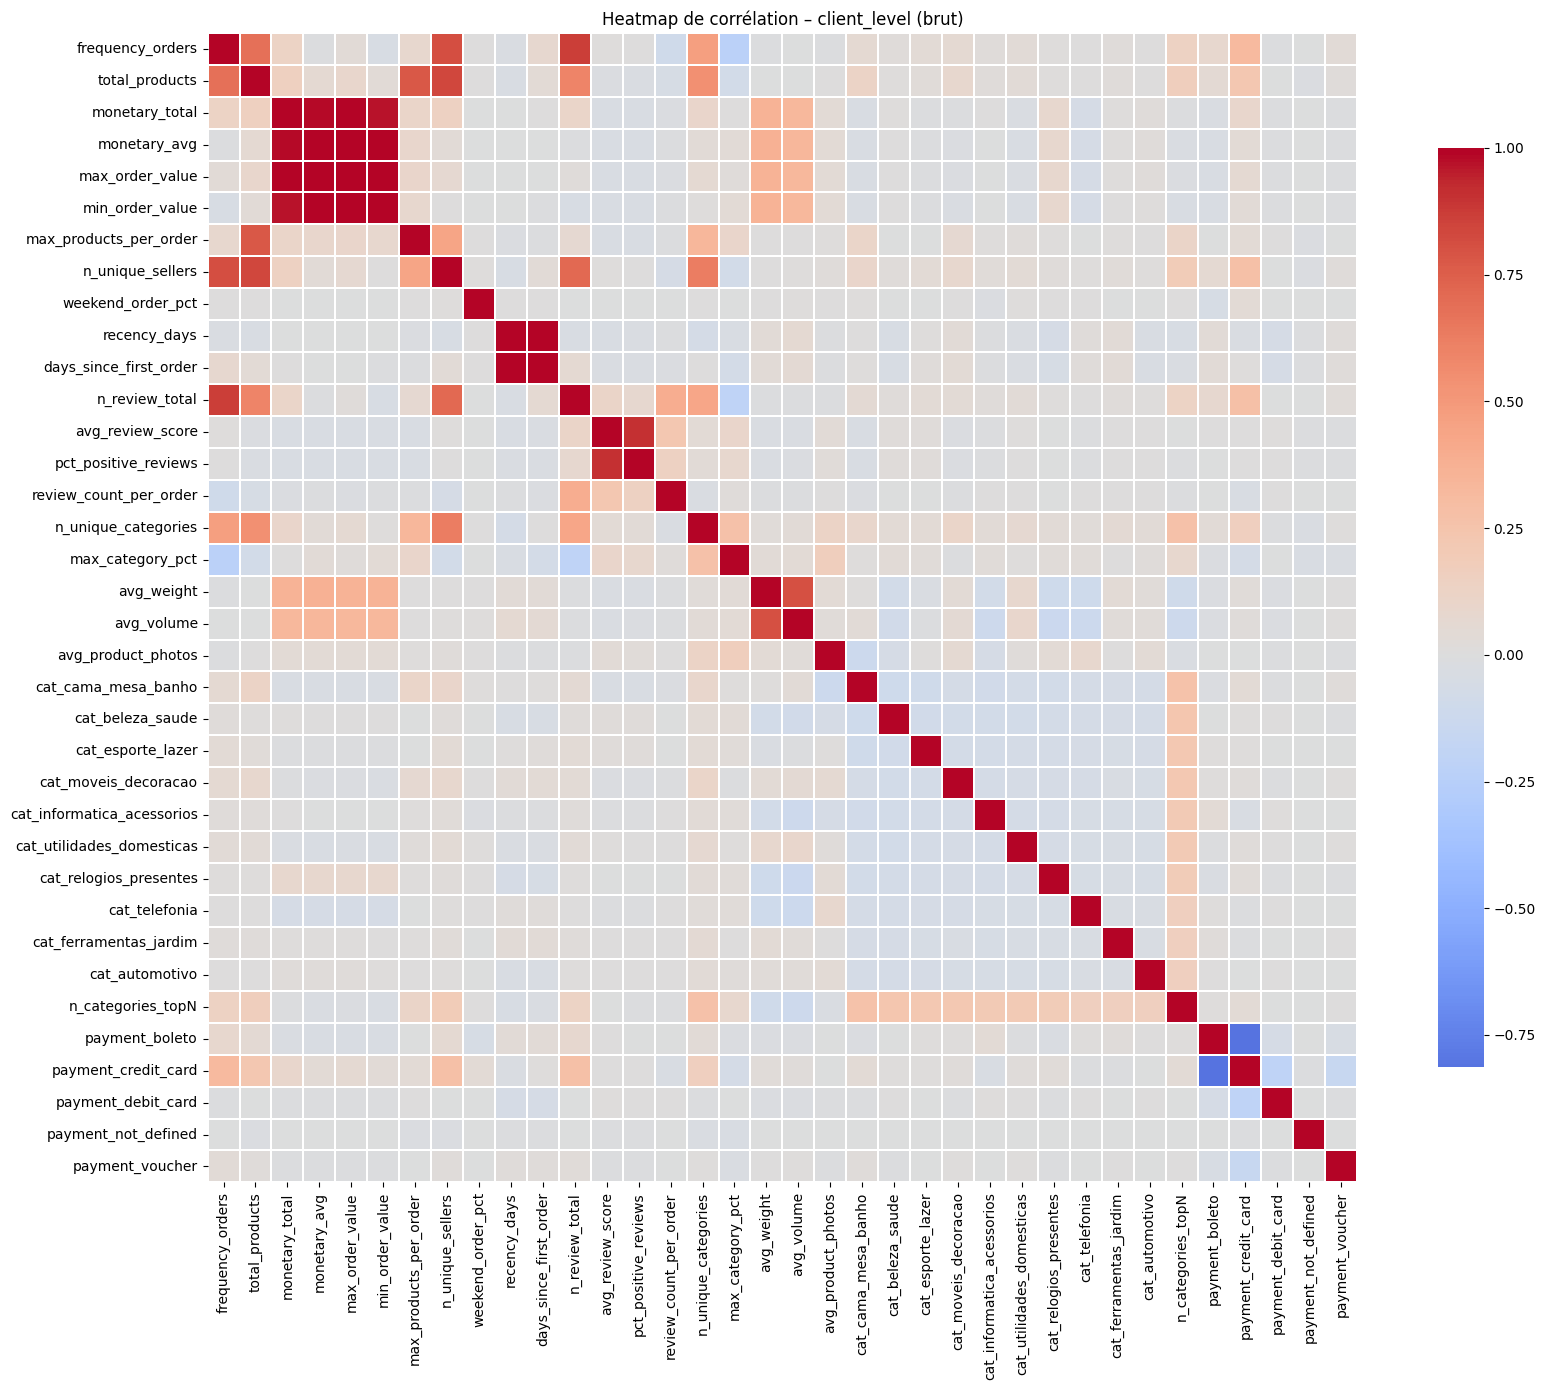

Matrice de corrélation arrondie à 2 décimales :


,frequency_orders,total_products,monetary_total,monetary_avg,max_order_value,min_order_value,max_products_per_order,n_unique_sellers,weekend_order_pct,recency_days,...,cat_relogios_presentes,cat_telefonia,cat_ferramentas_jardim,cat_automotivo,n_categories_topN,payment_boleto,payment_credit_card,payment_debit_card,payment_not_defined,payment_voucher
frequency_orders,1.00,0.68,0.12,-0.01,0.03,-0.04,0.08,0.81,0.00,-0.02,...,0.01,0.00,0.02,0.01,0.14,0.08,0.32,-0.01,-0.00,0.03
total_products,0.68,1.00,0.15,0.06,0.09,0.03,0.78,0.84,0.01,-0.03,...,0.01,0.00,0.02,0.01,0.17,0.05,0.23,-0.00,-0.01,0.02
monetary_total,0.12,0.15,1.00,0.98,0.99,0.97,0.10,0.14,-0.00,-0.01,...,0.08,-0.06,0.01,0.02,-0.01,-0.02,0.09,-0.01,-0.00,-0.01
monetary_avg,-0.01,0.06,0.98,1.00,1.00,1.00,0.09,0.04,-0.00,-0.00,...,0.08,-0.06,0.01,0.02,-0.03,-0.04,0.04,-0.01,-0.00,-0.01
max_order_value,0.03,0.09,0.99,1.00,1.00,0.99,0.09,0.07,-0.00,-0.00,...,0.08,-0.06,0.01,0.02,-0.02,-0.03,0.06,-0.01,-0.00,-0.01
min_order_value,-0.04,0.03,0.97,1.00,0.99,1.00,0.08,0.01,-0.00,-0.00,...,0.08,-0.06,0.01,0.01,-0.03,-0.04,0.03,-0.01,-0.00,-0.01
max_products_per_order,0.08,0.78,0.10,0.09,0.09,0.08,1.00,0.44,0.01,-0.02,...,0.01,-0.00,0.01,0.00,0.11,-0.00,0.04,0.00,-0.02,-0.00
n_unique_sellers,0.81,0.84,0.14,0.04,0.07,0.01,0.44,1.00,0.01,-0.05,...,0.02,0.01,0.02,0.01,0.19,0.06,0.27,-0.01,-0.02,0.02
weekend_order_pct,0.00,0.01,-0.00,-0.00,-0.00,-0.00,0.01,0.01,1.00,0.00,...,0.01,0.00,-0.00,-0.01,0.00,-0.05,0.05,-0.01,-0.00,-0.00
recency_days,-0.02,-0.03,-0.01,-0.00,-0.00,-0.00,-0.02,-0.05,0.00,1.00,...,-0.06,0.02,0.03,-0.04,-0.04,0.03,-0.02,-0.06,-0.01,0.02


In [ ]:
# # ==============================
# # MATRICE DE CORRÉLATION & HEATMAP
# # ==============================

# # 1. Sélection des colonnes numériques et suppression des colonnes à exclure
# cols_to_exclude = ['customer_unique_id', 'payment_customer_unique_id']
# numeric_cols = client_level.select_dtypes(include=[np.number]).drop(columns=cols_to_exclude, errors='ignore')

# # 2. Calcul de la matrice de corrélation
# corr_matrix = numeric_cols.corr()

# # 3. Heatmap seule (sans chiffres)
# plt.figure(figsize=(18, 14))
# sns.heatmap(
#     corr_matrix,
#     cmap="coolwarm",
#     center=0,
#     square=True,
#     linewidths=0.3,
#     cbar_kws={"shrink": 0.8}
# )
# plt.title("Heatmap de corrélation – client_level (brut)")
# plt.tight_layout()
# plt.show()

# # 4. Tableau avec valeurs exactes
# print("Matrice de corrélation arrondie à 2 décimales :")
# display(corr_matrix.round(2))


| Catégorie     | Variable                   | Statut recommandé    | Justification                                                 |
| ------------- | -------------------------- | -------------------- | ------------------------------------------------------------- |
| Identifiant   | customer_unique_id         | Garder (hors modèle) | Clé client, indispensable pour jointures mais à exclure du ML |
| Valeur client | monetary_total             | Garder               | Mesure globale de valeur, très discriminante                  |
| Valeur client | monetary_avg               | Supprimer            | Très corrélée à monetary_total, redondante                    |
| Valeur client | max_order_value            | Garder               | Capture les achats exceptionnels                              |
| Valeur client | min_order_value            | Supprimer            | Redondante, corrélée à max_order_value                        |
| Fréquence     | frequency_orders           | Optionnel            | Faible variance (majorité = 1), mais informative si gardée    |
| Produits      | total_products             | Supprimer            | Corrélée à frequency_orders                                   |
| Produits      | max_products_per_order     | Optionnel            | Faible variance                                               |
| Temporalité   | recency_days               | Garder               | Variable clé RFM                                              |
| Temporalité   | days_since_first_order     | Optionnel            | Corrélée à recency_days, utile pour cycle de vie              |
| Engagement    | n_review_total             | Garder               | Indicateur d’engagement client                                |
| Engagement    | avg_review_score           | Optionnel            | Beaucoup de zéros (clients sans review)                       |
| Engagement    | pct_positive_reviews       | Garder               | Plus robuste que la moyenne                                   |
| Engagement    | review_count_per_order     | Supprimer            | Corrélée à n_review_total / frequency_orders                  |
| Comportement  | weekend_order_pct          | Garder               | Habitude d’achat temporelle                                   |
| Diversité     | n_unique_categories        | Supprimer            | Très concentrée sur 1, corrélée à n_categories_topN           |
| Diversité     | n_categories_topN          | Garder               | Bonne synthèse de diversité                                   |
| Préférences   | max_category_pct           | Garder               | Mesure de spécialisation                                      |
| Produits      | avg_weight                 | Garder               | Typologie produits achetés                                    |
| Produits      | avg_volume                 | Garder               | Complémentaire au poids                                       |
| Produits      | avg_product_photos         | Garder               | Proxy d’intérêt produit                                       |
| Catégories    | cat_* (one-hot)            | Optionnel            | Garder uniquement top 5–8 catégories les plus représentatives |
| Paiement      | payment_*                  | À transformer        | Préférer mode dominant ou % credit card                       |
| Paiement      | payment_customer_unique_id | Supprimer            | Colonne parasite                                              |
| Qualité       | has_review (à créer)       | Recommandé           | Distingue 0 review vs mauvaise note                           |


In [ ]:
# # ==============================
# # 1. Copie de travail
# # ==============================
# df = client_level.copy()
# # On part de la table client_level complète, y compris frequency_orders

# # ==============================
# # 2. Gestion des reviews
# # ==============================
# df['has_review'] = (df['n_review_total'] > 0).astype(int)
# # 1 si le client a fait au moins une review, 0 sinon

# # Mettre NaN pour avg_review_score et pct_positive_reviews si pas de review
# for col in ['pct_positive_reviews', 'avg_review_score']:
#     if col in df.columns:
#         df.loc[df['has_review'] == 0, col] = np.nan
# # Justification : évite de biaiser les moyennes si le client n'a jamais fait de review

# # ==============================
# # 3. Paiement : proportion carte de crédit
# # ==============================
# payment_cols = [c for c in df.columns if c.startswith('payment_')]
# if payment_cols and 'payment_credit_card' in df.columns:
#     df[payment_cols] = df[payment_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
#     df['pct_credit_card'] = df['payment_credit_card'] / df[payment_cols].sum(axis=1)

# # Supprimer les colonnes de paiement originales et clé parasite
# df = df.drop(columns=payment_cols + ['payment_customer_unique_id'], errors='ignore')

# # ==============================
# # 4. Catégories produits : garder top N
# # ==============================
# cat_cols = [c for c in df.columns if c.startswith('cat_')]
# TOP_N = 8
# if cat_cols:
#     cat_freq = df[cat_cols].mean().sort_values(ascending=False)
#     top_cat_cols = cat_freq.head(TOP_N).index.tolist()
#     df = df.drop(columns=[c for c in cat_cols if c not in top_cat_cols], errors='ignore')

# # ==============================
# # 5. Colonnes finales pour clustering
# # ==============================
# final_features = [
#     # RFM
#     'recency_days', 'monetary_total', 'frequency_orders',

#     # Engagement / avis
#     'n_review_total', 'pct_positive_reviews',

#     # Comportement client
#     'weekend_order_pct', 'avg_product_photos',

#     # Diversité / préférences produits
#     'n_categories_topN', 'max_category_pct', 'avg_weight', 'avg_volume',

#     # Paiement
#     'pct_credit_card',

#     # Indicateur review
#     'has_review'
# ] + top_cat_cols

# # Filtrage final pour ne garder que les colonnes existantes
# client_level_V2 = df[[c for c in final_features if c in df.columns]].copy()

# # ==============================
# # 6. Remplir NaN avant clustering
# # ==============================
# # KMeans ne supporte pas les NaN
# # On peut remplir par 0 ou la médiane selon la variable
# client_level_V2 = client_level_V2.fillna(0)

# # ==============================
# # 7. Vérifications finales
# # ==============================
# print("Shape df client_level_V2 :", client_level_V2.shape)
# profile_df = profile_dataframe(client_level_V2, "client_level_V2", primary_keys)
# display(profile_df)


Shape df client_level_V2 : (96096, 21)

=== Table : client_level_V2 ===
Taille : 96096 lignes × 21 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,recency_days,160.0,int64,numérique,630,NaN,0.0,0.00,0.0,163.00,268.00,397.0000,772.00,287.74
1,monetary_total,141.9,float64,numérique,31718,NaN,0.0,0.70,0.0,62.39,107.27,182.2375,13664.08,164.87
2,frequency_orders,1.0,int64,numérique,9,NaN,0.0,0.00,1.0,1.00,1.00,1.0000,17.00,1.03
3,n_review_total,1.0,float64,numérique,10,NaN,0.0,0.75,0.0,1.00,1.00,1.0000,17.00,1.02
4,pct_positive_reviews,1.0,float64,numérique,14,NaN,0.0,23.17,0.0,1.00,1.00,1.0000,1.00,0.76
5,weekend_order_pct,0.0,float64,numérique,11,NaN,0.0,76.66,0.0,0.00,0.00,0.0000,1.00,0.23
6,avg_product_photos,1.0,float64,numérique,101,NaN,0.0,2.07,0.0,1.00,1.50,3.0000,20.00,2.21
7,n_categories_topN,1.0,float64,numérique,5,NaN,0.0,37.36,0.0,0.00,1.00,1.0000,4.00,0.64
8,max_category_pct,1.0,float64,numérique,27,NaN,0.0,2.07,0.0,1.00,1.00,1.0000,1.00,0.97
9,avg_weight,1500.0,float64,numérique,3270,NaN,0.0,0.72,0.0,300.00,700.00,1813.0000,40425.00,2092.04


In [ ]:
# # ==============================
# # 1. Copie de travail
# # ==============================
# df = client_level_V2.copy()

# # ==============================
# # 2. Supprimer les variables redondantes ou peu informatives
# # ==============================
# # - 'max_order_value' corrélée à 'monetary_total' (~0.99)
# # - 'has_review' redondant avec 'n_review_total'
# # - 'pct_positive_reviews' trop de NaN
# redundant_cols = ['max_order_value', 'has_review', 'pct_positive_reviews']
# df = df.drop(columns=[c for c in redundant_cols if c in df.columns])

# # ==============================
# # 3. Catégories produits : garder top 5
# # ==============================
# cat_cols = [c for c in df.columns if c.startswith('cat_')]
# if cat_cols:
#     cat_freq = df[cat_cols].mean().sort_values(ascending=False)
#     top_cat_cols = cat_freq.head(5).index.tolist()  # Top 5 catégories
#     df = df.drop(columns=[c for c in cat_cols if c not in top_cat_cols], errors='ignore')

# # ==============================
# # 4. Colonnes finales pour clustering
# # ==============================
# final_features = [
#     # RFM / valeur
#     'recency_days', 'monetary_total', 'frequency_orders',

#     # Engagement / avis
#     'n_review_total',

#     # Comportement client
#     'weekend_order_pct', 'avg_product_photos',

#     # Diversité / préférences produits
#     'n_categories_topN', 'max_category_pct', 'avg_weight', 'avg_volume',

#     # Paiement
#     'pct_credit_card'
# ] + top_cat_cols

# # Filtrage final pour garder uniquement les colonnes existantes
# client_level_V3 = df[[c for c in final_features if c in df.columns]].copy()

# # ==============================
# # 5. Remplir NaN pour clustering
# # ==============================
# client_level_V3 = client_level_V3.fillna(0)
# # KMeans ne supporte pas les NaN, on remplace par 0 ou médiane si nécessaire

# # ==============================
# # 6. Vérifications finales
# # ==============================
# print("Shape df client_level_V3 :", client_level_V3.shape)
# profile_df = profile_dataframe(client_level_V3, "client_level_V3", primary_keys)
# display(profile_df)


Shape df client_level_V3 : (96096, 16)

=== Table : client_level_V3 ===
Taille : 96096 lignes × 16 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,recency_days,160.0,int64,numérique,630,NaN,0.0,0.00,0.0,163.00,268.00,397.0000,772.00,287.74
1,monetary_total,141.9,float64,numérique,31718,NaN,0.0,0.70,0.0,62.39,107.27,182.2375,13664.08,164.87
2,frequency_orders,1.0,int64,numérique,9,NaN,0.0,0.00,1.0,1.00,1.00,1.0000,17.00,1.03
3,n_review_total,1.0,float64,numérique,10,NaN,0.0,0.75,0.0,1.00,1.00,1.0000,17.00,1.02
4,weekend_order_pct,0.0,float64,numérique,11,NaN,0.0,76.66,0.0,0.00,0.00,0.0000,1.00,0.23
5,avg_product_photos,1.0,float64,numérique,101,NaN,0.0,2.07,0.0,1.00,1.50,3.0000,20.00,2.21
6,n_categories_topN,1.0,float64,numérique,5,NaN,0.0,37.36,0.0,0.00,1.00,1.0000,4.00,0.64
7,max_category_pct,1.0,float64,numérique,27,NaN,0.0,2.07,0.0,1.00,1.00,1.0000,1.00,0.97
8,avg_weight,1500.0,float64,numérique,3270,NaN,0.0,0.72,0.0,300.00,700.00,1813.0000,40425.00,2092.04
9,avg_volume,7616.0,float64,numérique,7383,NaN,0.0,0.72,0.0,2816.00,6400.00,18042.0000,296208.00,15137.10


| Catégorie            | Variable                   | Description / Rôle                                          |
| -------------------- | -------------------------- | ----------------------------------------------------------- |
| RFM / Temporalité    | recency_days               | Temps depuis la dernière commande, clé pour segmentation    |
| Valeur client        | monetary_total             | Valeur totale du client, très discriminante                 |
| RFM / Fréquence      | frequency_orders           | Nombre de commandes passées par le client                   |
| Engagement client    | n_review_total             | Nombre total de reviews, mesure de l’engagement             |
| Comportement client  | weekend_order_pct          | Pourcentage de commandes le week-end, habitude temporelle   |
| Intérêt produit      | avg_product_photos         | Nombre moyen de photos vues/produits, proxy d’intérêt       |
| Diversité des achats | n_categories_topN          | Nombre de catégories achetées (top N), diversité            |
| Spécialisation       | max_category_pct           | Pourcentage maximal sur une catégorie, spécialisation       |
| Typologie produits   | avg_weight                 | Poids moyen des produits achetés                            |
| Typologie produits   | avg_volume                 | Volume moyen des produits achetés                           |
| Paiement             | pct_credit_card            | Proportion des paiements par carte de crédit                |
| Catégories produits  | cat_cama_mesa_banho        | Catégorie la plus fréquente (top N)                         |
| Catégories produits  | cat_beleza_saude           | Catégorie la plus fréquente (top N)                         |
| Catégories produits  | cat_esporte_lazer          | Catégorie la plus fréquente (top N)                         |
| Catégories produits  | cat_informatica_acessorios | Catégorie la plus fréquente (top N)                         |
| Catégories produits  | cat_moveis_decoracao       | Catégorie la plus fréquente (top N)                         |


# **SEGMENTATION RFM**

In [ ]:
# def rfm_segmentation(df, recency_col='recency_days', frequency_col='frequency_orders', monetary_col='monetary_total',
#                      recency_thresholds=(30, 60, 90, 180, 365), frequency_thresholds=(5, 3, 1, 1), monetary_threshold=500):
#     """
#     Segmente les clients en fonction des règles RFM.
    
#     Paramètres :
#     - df : DataFrame contenant les colonnes de recency, frequency et monetary
#     - recency_col : nom de la colonne pour la récence (jours depuis la dernière commande)
#     - frequency_col : nom de la colonne pour la fréquence (nombre de commandes)
#     - monetary_col : nom de la colonne pour le montant total dépensé
#     - recency_thresholds : tuple des seuils pour recency (ordre : champions, loyal, potential loyal, to reactivate, lost)
#     - frequency_thresholds : tuple des seuils pour frequency (ordre : champions, loyal, potential loyal, to reactivate)
#     - monetary_threshold : seuil pour monetary pour le segment "champions"
    
#     Retourne :
#     - df avec une nouvelle colonne 'rfm_segment'
#     """
    
#     def assign_segment(row):
#         # Champions
#         if row[recency_col] <= recency_thresholds[0] and row[frequency_col] >= frequency_thresholds[0] and row[monetary_col] >= monetary_threshold:
#             return "champions"
#         # Loyal
#         elif row[recency_col] <= recency_thresholds[1] and row[frequency_col] >= frequency_thresholds[1]:
#             return "loyal"
#         # Potential loyal
#         elif row[recency_col] <= recency_thresholds[2] and row[frequency_col] >= frequency_thresholds[2]:
#             return "potential loyal"
#         # To reactivate
#         elif row[recency_col] > recency_thresholds[3] and row[frequency_col] >= frequency_thresholds[3]:
#             return "to reactivate"
#         # Lost
#         elif row[recency_col] > recency_thresholds[4]:
#             return "lost"
#         # At risk
#         else:
#             return "at risk"
    
#     df = df.copy()
#     df['rfm_segment'] = df.apply(assign_segment, axis=1)
#     return df

In [ ]:
# df_rfm_segment = rfm_segmentation(
#     client_level_V3,
#     recency_col='recency_days',
#     frequency_col='frequency_orders',
#     monetary_col='monetary_total',
#     recency_thresholds=(30, 90, 180, 365, np.inf),
#     frequency_thresholds=(2, 1, 1, 0),
#     monetary_threshold=150
# )


--- Pourcentage par segment RFM ---
 rfm_segment
at risk            41.37
to reactivate      29.51
potential loyal    19.06
loyal              10.05
champions           0.00
Name: proportion, dtype: float64


C:\Users\barre\AppData\Local\Temp\ipykernel_12672\844357925.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=colors)


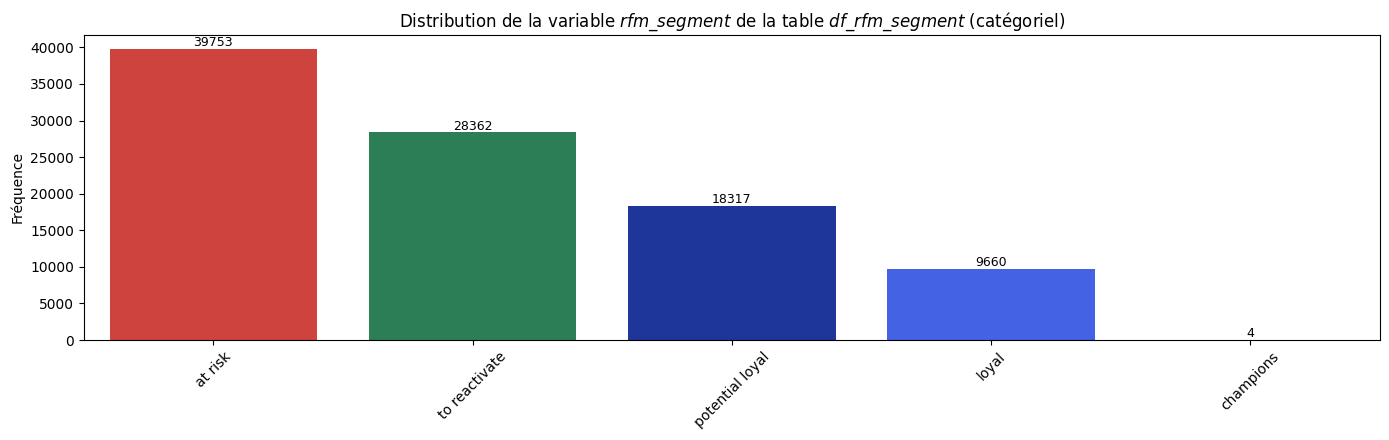

In [ ]:
# color_segment = {
#     "loyal": "#2851FF",
#     "potential loyal": "#092AAE",
#     "champions": "#15C574",
#     "to reactivate": "#1D8C56",
#     "lost": "#910909",
#     "at risk": "#E72C26"
# }
# pct_rfm_segment = df_rfm_segment['rfm_segment'].value_counts(normalize=True) * 100
# print("\n--- Pourcentage par segment RFM ---\n", pct_rfm_segment.round(2))
# plot_distributions(df_rfm_segment, ["rfm_segment"], table_name="df_rfm_segment", show_values=True, color_dict=color_segment)

# **K-MEANS**

In [61]:
# ==============================
# 1. Copie de travail
# ==============================
df_k_means = client_level_V3.copy()

# ==============================
# 2. Identifier variables continues et binaires
# ==============================
binary_cols = [c for c in df_k_means.columns if set(df_k_means[c].unique()).issubset({0,1})]
continuous_cols = [c for c in df_k_means.columns if c not in binary_cols]

# ==============================
# 3. Normalisation des variables continues
# ==============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_k_means[continuous_cols] = scaler.fit_transform(df_k_means[continuous_cols])

# ==============================
# 4. Vérifications finales
# ==============================
print("Shape df df_k_means :", df_k_means.shape)
profile_df = profile_dataframe(df_k_means, "df_k_means", primary_keys)
display(profile_df)

Shape df df_k_means : (96096, 16)

=== Table : df_k_means ===
Taille : 96096 lignes × 16 colonnes
Clé primaire : non renseignée

--- Tableau de profil ---


,column,first_value,dtype,detailed_type,n_unique,pct_duplicates,pct_missing,pct_zeros,min,q25,median,q75,max,mean
0,recency_days,-0.832621,float64,numérique,630,NaN,0.0,0.00,-1.875552,-0.813067,-0.128643,0.712219,3.156587,0.00
1,monetary_total,-0.100783,float64,numérique,31227,NaN,0.0,0.00,-0.723322,-0.449606,-0.252710,0.076185,59.223294,-0.00
2,frequency_orders,-0.162368,float64,numérique,9,NaN,0.0,0.00,-0.162368,-0.162368,-0.162368,-0.162368,74.470541,-0.00
3,n_review_total,-0.107988,float64,numérique,10,NaN,0.0,0.00,-4.592518,-0.107988,-0.107988,-0.107988,71.644489,0.00
4,weekend_order_pct,-0.548806,float64,numérique,11,NaN,0.0,0.00,-0.548806,-0.548806,-0.548806,-0.548806,1.840706,-0.00
5,avg_product_photos,-0.691720,float64,numérique,101,NaN,0.0,0.00,-1.264117,-0.691720,-0.405521,0.453075,10.183830,-0.00
6,n_categories_topN,0.728211,float64,numérique,5,NaN,0.0,0.00,-1.269853,-1.269853,0.728211,0.728211,6.722404,0.00
7,max_category_pct,0.198986,float64,numérique,27,NaN,0.0,0.00,-6.145635,0.198986,0.198986,0.198986,0.198986,-0.00
8,avg_weight,-0.158599,float64,numérique,3270,NaN,0.0,0.00,-0.560429,-0.480063,-0.372909,-0.074751,10.268892,-0.00
9,avg_volume,-0.323276,float64,numérique,7383,NaN,0.0,0.00,-0.650632,-0.529593,-0.375543,0.124860,12.081153,-0.00


In [62]:
# CLUSTERING AVEC K-MEANS

# --- Paramètres initiaux ---
n_clusters_init = 4  # test initial
random_state = 42

# --- Initialisation et fit ---
kmeans_init = KMeans(n_clusters=n_clusters_init, random_state=random_state)
cluster_labels_init = kmeans_init.fit_predict(df_k_means)

# --- Ajout des labels au df pour analyse ---
df_k_means['cluster_init'] = cluster_labels_init

# --- Vérification ---
print("Distribution des clusters initiaux :")
print(df_k_means['cluster_init'].value_counts())

Distribution des clusters initiaux :
cluster_init
2    41490
1    26601
0    25246
3     2759
Name: count, dtype: int64


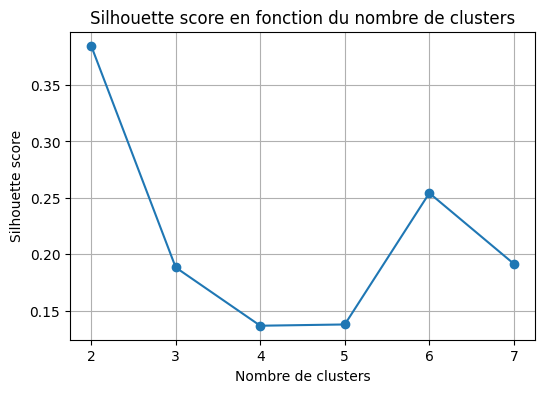

,n_clusters,silhouette_score
0,2,0.384781
1,3,0.188378
2,4,0.136772
3,5,0.137887
4,6,0.254269
5,7,0.191569


Nombre optimal de clusters selon silhouette : 2


In [65]:
# --- Paramètres ---
range_n_clusters = range(2, 8)
silhouette_scores = []

# Préparer les données pour le clustering (sans cluster_init si elle existe)
df_for_clustering = df_k_means.drop(columns=['cluster_init'], errors='ignore')

# --- Calcul des scores silhouette ---
for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    labels = kmeans.fit_predict(df_for_clustering)
    score = silhouette_score(df_for_clustering, labels)
    silhouette_scores.append(score)

# --- Affichage de la courbe ---
plt.figure(figsize=(6,4))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title("Silhouette score en fonction du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

# --- Tableau des résultats ---
results_df = pd.DataFrame({
    "n_clusters": list(range_n_clusters),
    "silhouette_score": silhouette_scores
})

display(results_df)

# --- Meilleur nombre de clusters selon silhouette ---
best_k = results_df.loc[results_df['silhouette_score'].idxmax(), 'n_clusters']
print("Nombre optimal de clusters selon silhouette :", best_k)


In [ ]:
# ==============================
# CLUSTERING FINAL AVEC PIC 6
# ==============================

n_clusters_final = 6
random_state = 42

# --- Fit KMeans final ---
kmeans_final = KMeans(n_clusters=n_clusters_final, random_state=random_state)
df_k_means['cluster'] = kmeans_final.fit_predict(df_k_means.drop(columns=['cluster_init'], errors='ignore'))

# --- Vérifications quantitatives ---
inertia = kmeans_final.inertia_
sil_score = silhouette_score(df_k_means.drop(columns=['cluster_init', 'cluster'], errors='ignore'), 
                             df_k_means['cluster'])

print(f"Inertia (somme des distances au centre) : {inertia:.2f}")
print(f"Silhouette score : {sil_score:.3f}")

# --- Distribution des clusters ---
print("\nDistribution des clusters :")
print(df_k_means['cluster'].value_counts())

Inertia (somme des distances au centre) : 557518.60
Silhouette score : 0.254

Distribution des clusters :
cluster
2    64720
0    19622
1     6846
4     2693
5     2001
3      214
Name: count, dtype: int64


,recency_days,monetary_total,frequency_orders,n_review_total,weekend_order_pct,avg_product_photos,n_categories_topN,max_category_pct,avg_weight,avg_volume,pct_credit_card,cat_cama_mesa_banho,cat_beleza_saude,cat_esporte_lazer,cat_informatica_acessorios,cat_moveis_decoracao,cluster_init
cluster,,,,,,,,,,,,,,,,,
0,-0.001868,-0.120786,-0.154761,-0.138384,1.840706,0.028888,0.037616,0.173747,-0.192719,-0.172515,0.806798,0.103048,0.092957,0.077668,0.065386,0.067170,0.009836
1,0.094448,1.393792,-0.146016,-0.143361,-0.083189,0.124724,-0.513355,0.170477,2.775618,2.569425,0.782793,0.055799,0.022787,0.037978,0.009056,0.073766,0.200409
2,-0.015964,-0.128802,-0.160062,-0.137021,-0.548806,0.019957,0.045467,0.181138,-0.223282,-0.206680,0.752457,0.094932,0.097976,0.082278,0.076174,0.062438,1.636109
3,-0.302932,1.556271,11.259257,10.747089,0.025810,-0.013130,1.475151,-1.842724,-0.096212,-0.089512,0.728972,0.266355,0.144860,0.191589,0.102804,0.172897,3.000000
4,-0.125799,0.534351,4.564544,3.928589,-0.004740,-0.076224,0.760115,-1.376221,-0.048594,-0.045782,0.744523,0.199777,0.121055,0.135537,0.096547,0.154103,2.899369
5,0.413201,-0.303769,-0.153044,-0.157293,-0.011434,-1.251483,-1.263862,-6.096488,-0.308875,-0.343039,0.740130,0.001000,0.000000,0.000000,0.000000,0.000500,0.976512


| Critère / Observation                     | Détail |
|-------------------------------------------|--------|
| **Silhouette score**                       | 0.254 → cohérence moyenne avec 6 clusters |
| **Cohésion interne des clusters**         | Moyenne, acceptable si le choix est métier |
| **Distribution des clusters**             | Très déséquilibrée |
| Cluster 2                                  | 64 720 clients → majoritaire |
| Cluster 3                                  | 214 clients → très petit |
| Autres clusters                            | Intermédiaires |
| **Profil moyen des clusters**             |  |
| Cluster 3                                  | Extrêmes sur `frequency_orders` et `n_review_total` → clients très actifs / reviewers intensifs |
| Cluster 5                                  | Valeurs négatives sur features normalisées → clients en retrait par rapport à la moyenne |
| Clusters 0 & 2                             | Similaires, surtout `recency_days` et `monetary_total` → clients “moyens” |
| Colonnes binaires                          | `cat_*` et `pct_credit_card` distinguent certaines préférences produits |
| **Conclusion**                             | Choix du pic à 6 clusters justifié pour segmenter les niches (clusters extrêmes comme 3 ou 5) |
| Inconvénient                               | Clusters très déséquilibrés → fusion ou traitement séparé des petits clusters possible |
| Remarque métrique                          | Silhouette pas parfaite, mais pic métier peut primer sur la métrique pure |


,nb_clients,recency_days,monetary_total,frequency_orders,n_review_total,weekend_order_pct,avg_product_photos,n_categories_topN,max_category_pct,avg_weight,avg_volume,pct_credit_card,cat_cama_mesa_banho,cat_beleza_saude,cat_esporte_lazer,cat_informatica_acessorios,cat_moveis_decoracao
cluster,,,,,,,,,,,,,,,,,
2,64720,-0.02,-0.13,-0.16,-0.14,-0.55,0.02,0.05,0.18,-0.22,-0.21,0.75,0.09,0.10,0.08,0.08,0.06
0,19622,-0.00,-0.12,-0.15,-0.14,1.84,0.03,0.04,0.17,-0.19,-0.17,0.81,0.10,0.09,0.08,0.07,0.07
1,6846,0.09,1.39,-0.15,-0.14,-0.08,0.12,-0.51,0.17,2.78,2.57,0.78,0.06,0.02,0.04,0.01,0.07
4,2693,-0.13,0.53,4.56,3.93,-0.00,-0.08,0.76,-1.38,-0.05,-0.05,0.74,0.20,0.12,0.14,0.10,0.15
5,2001,0.41,-0.30,-0.15,-0.16,-0.01,-1.25,-1.26,-6.10,-0.31,-0.34,0.74,0.00,0.00,0.00,0.00,0.00
3,214,-0.30,1.56,11.26,10.75,0.03,-0.01,1.48,-1.84,-0.10,-0.09,0.73,0.27,0.14,0.19,0.10,0.17


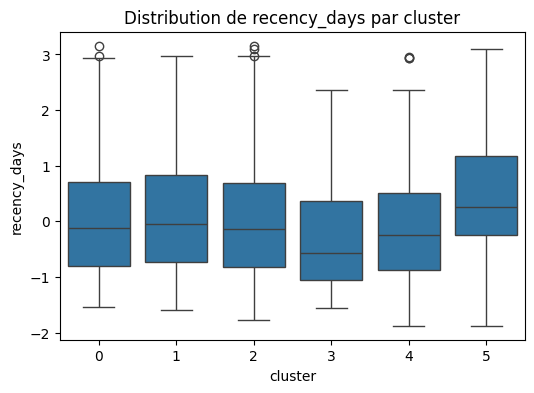

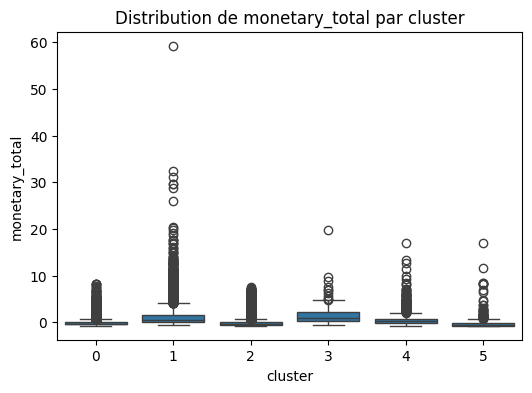

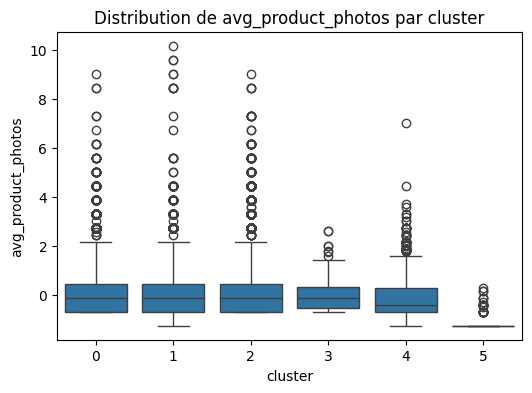

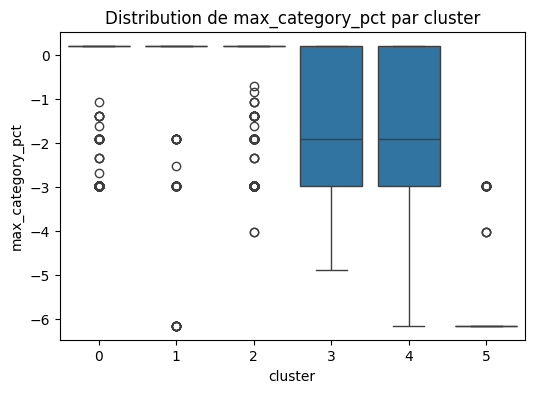

In [69]:
# ==============================
# INTERPRÉTATION DES CLUSTERS
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# --- Colonnes continues pour interprétation ---
cols_continuous = [
    'recency_days', 'monetary_total', 'frequency_orders', 'n_review_total',
    'weekend_order_pct', 'avg_product_photos', 'n_categories_topN',
    'max_category_pct', 'avg_weight', 'avg_volume', 'pct_credit_card'
]

# --- Colonnes binaires / catégorielles ---
cols_binary = [c for c in df_k_means.columns if c.startswith('cat_')]

# --- Vérifier que toutes les colonnes existent ---
cols_continuous = [c for c in cols_continuous if c in df_k_means.columns]

# ==============================
# Tableau résumé moyen + taille clusters
# ==============================
cluster_summary = df_k_means.groupby('cluster')[cols_continuous + cols_binary].mean()
cluster_summary['nb_clients'] = df_k_means.groupby('cluster').size()

# Réorganiser colonnes pour lisibilité
cols_order = ['nb_clients'] + cols_continuous + cols_binary
cluster_summary = cluster_summary[cols_order].round(2)

# Affichage trié par taille de cluster
display(cluster_summary.sort_values('nb_clients', ascending=False))

# ==============================
# Boxplots pour visualisation des features clés
# ==============================
features_to_plot = ['recency_days', 'monetary_total', 'avg_product_photos', 'max_category_pct']
features_to_plot = [f for f in features_to_plot if f in df_k_means.columns]

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=feature, data=df_k_means)
    plt.title(f"Distribution de {feature} par cluster")
    plt.show()


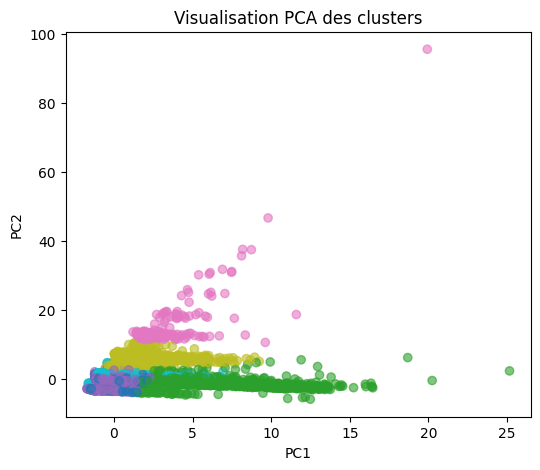

In [70]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_k_means.drop(columns=['cluster', 'cluster_init']))

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_k_means['cluster'], cmap='tab10', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisation PCA des clusters")
plt.show()


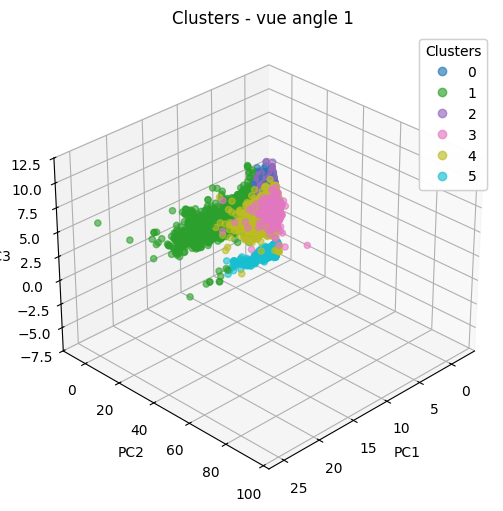

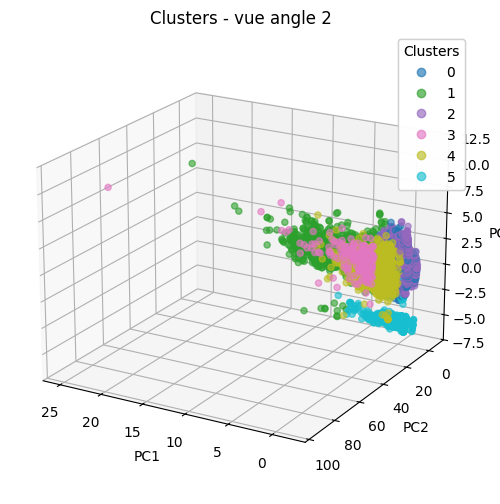

In [75]:
# --- Réduction à 3 dimensions ---
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # nécessaire pour plot 3D

pca = PCA(n_components=3)
X_pca = pca.fit_transform(df_k_means.drop(columns=['cluster', 'cluster_init'], errors='ignore'))

# --- Fonction pour afficher le scatter 3D avec angle personnalisé ---
def plot_3d_clusters(X, labels, elev=30, azim=45, title="Visualisation 3D des clusters"):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        X[:,0], X[:,1], X[:,2],
        c=labels, cmap='tab10', alpha=0.6
    )
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)
    plt.show()

# --- Angle 1 ---
plot_3d_clusters(X_pca, df_k_means['cluster'], elev=30, azim=45, title="Clusters - vue angle 1")

# --- Angle 2 ---
plot_3d_clusters(X_pca, df_k_means['cluster'], elev=20, azim=120, title="Clusters - vue angle 2")


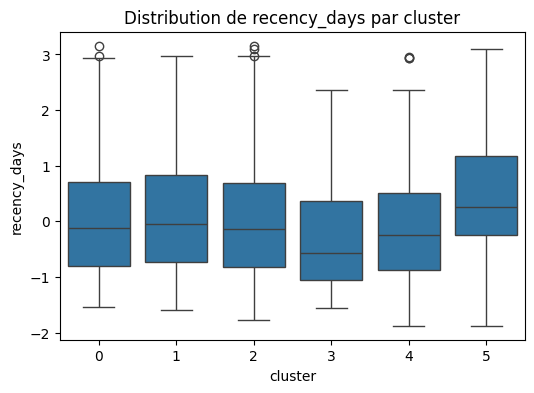

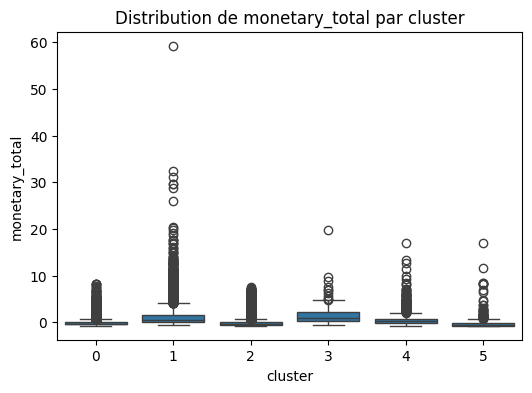

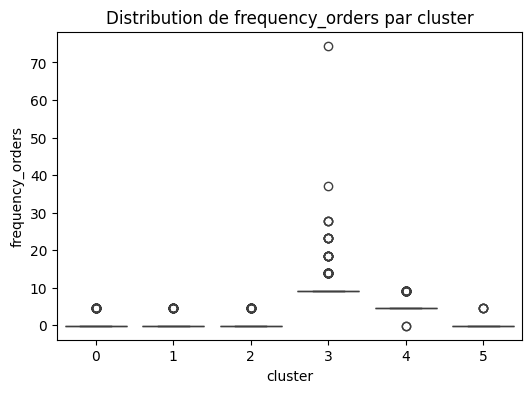

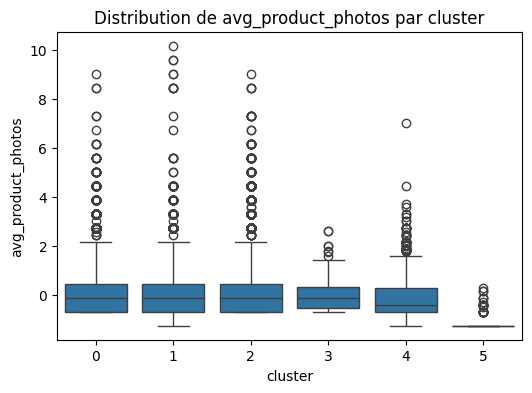

In [71]:
import seaborn as sns

features_to_plot = ['recency_days', 'monetary_total', 'frequency_orders', 'avg_product_photos']

for feature in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='cluster', y=feature, data=df_k_means)
    plt.title(f"Distribution de {feature} par cluster")
    plt.show()


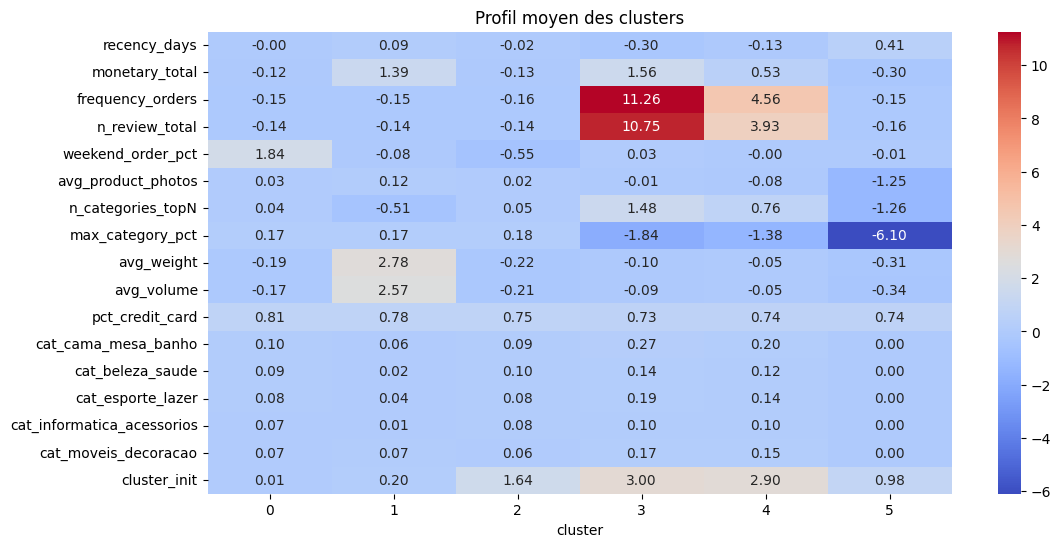

In [72]:
import seaborn as sns

cluster_means = df_k_means.groupby('cluster').mean()
plt.figure(figsize=(12,6))
sns.heatmap(cluster_means.T, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Profil moyen des clusters")
plt.show()


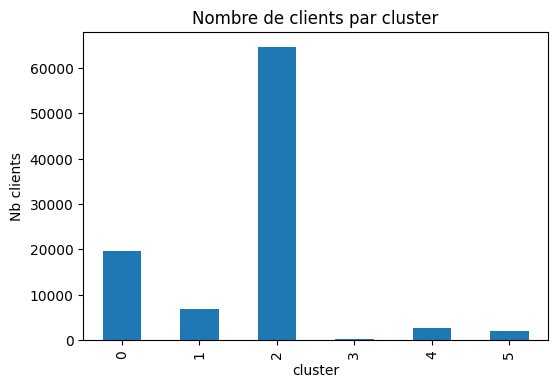

In [73]:
df_k_means['cluster'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.title("Nombre de clients par cluster")
plt.ylabel("Nb clients")
plt.show()
